In [1]:
import numpy as np

import gropt
from gropt.diffusion import DiffParams, te_search, sweep
from gropt.plot import plot_diff

gropt.setup_logging(3)

  TE=122.00 ms (N=531) -> b=   442.4 conv=True  infeasible


  TE=202.00 ms (N=931) -> b=  2681.0 conv=True  feasible


  TE= 42.00 ms (N=131) -> b=     0.7 conv=True  infeasible


  TE=161.80 ms (N=730) -> b=  1228.8 conv=True  feasible


  TE=142.00 ms (N=631) -> b=   766.9 conv=True  infeasible


...

  TE=156.80 ms (N=705) -> b=  1096.5 conv=True  feasible


  TE=154.40 ms (N=693) -> b=  1037.3 conv=True  feasible


  TE=153.20 ms (N=687) -> b=  1008.5 conv=True  feasible


  TE=152.60 ms (N=684) -> b=   996.7 conv=True  infeasible


  TE=152.80 ms (N=685) -> b=   999.0 conv=True  feasible


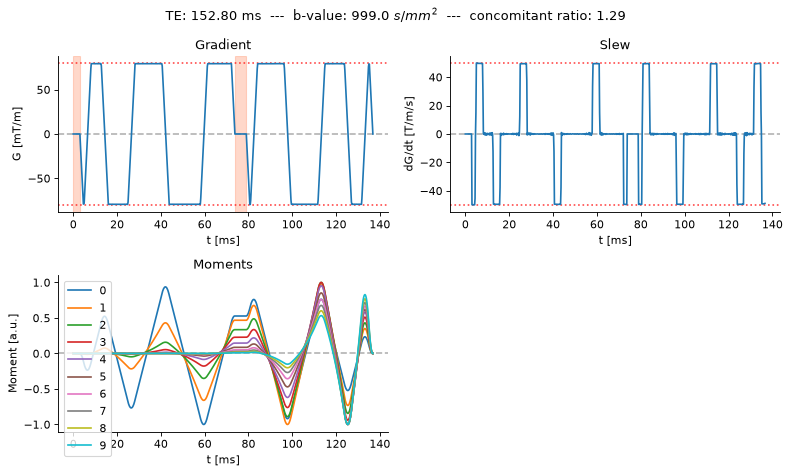

Search time: 156.10 ms


In [2]:
# Problem definition
cfg = DiffParams(
    TE=50e-3,
    T_90=3e-3,
    T_180=5e-3,
    T_readout=16e-3,
    dt=200e-6,
    gmax=0.08,
    smax=50.0,
    MMT=9,
)

res = te_search(cfg, target_b=1000, mode="obj", verbose=True)
plot_diff(res['cfg'], res['result'])

print(f'Search time: {1000*res["search_time"]:.2f} ms')

  TE=122.00 ms (N=266) -> b= 46338.4 conv=True  feasible


  TE= 42.00 ms (N=66) -> b=   188.5 conv=True  infeasible


  TE= 82.00 ms (N=166) -> b=  9195.3 conv=True  feasible


  TE= 61.60 ms (N=115) -> b=  2609.2 conv=True  feasible


  TE= 52.00 ms (N=91) -> b=  1202.7 conv=True  feasible


  TE= 46.80 ms (N=78) -> b=   664.8 conv=True  infeasible


  TE= 49.20 ms (N=84) -> b=   914.2 conv=True  infeasible


  TE= 50.40 ms (N=87) -> b=  1044.6 conv=True  feasible


  TE= 50.00 ms (N=86) -> b=   983.0 conv=True  infeasible


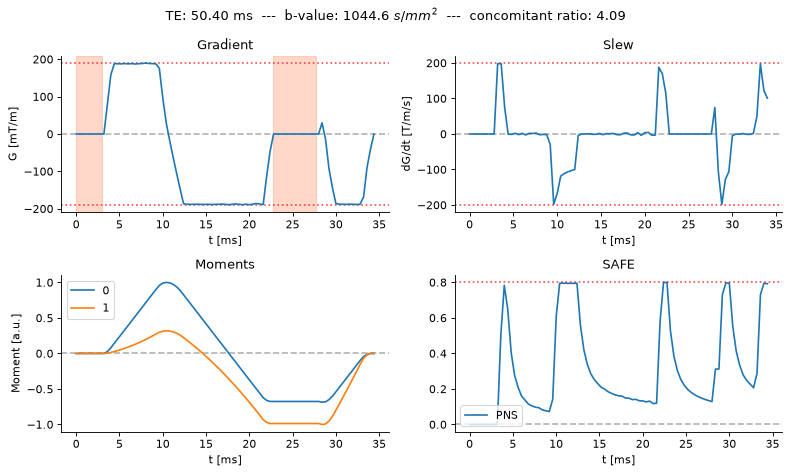

Search time: 111.37 ms


In [3]:
# Problem definition
cfg = DiffParams(
    TE=50e-3,
    T_90=3e-3,
    T_180=5e-3,
    T_readout=16e-3,
    dt=400e-6,
    gmax=0.19,
    smax=200.0,
    pns_lim = 0.8,
    # cns_lim = 0.8,
    MMT=1,
)

res = te_search(cfg, target_b=1000, mode="obj", verbose=True)
plot_diff(res['cfg'], res['result'])

print(f'Search time: {1000*res["search_time"]:.2f} ms')

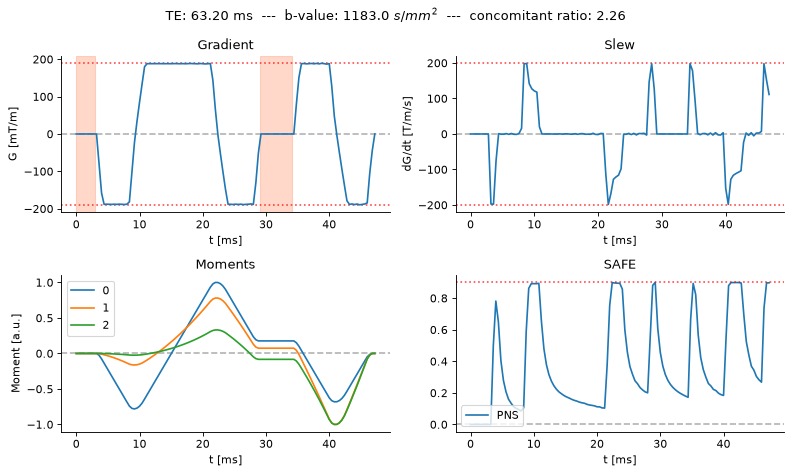

Search time: 131.59 ms


In [4]:
# Problem definition
cfg = DiffParams(
    TE=50e-3,
    T_90=3e-3,
    T_180=5e-3,
    T_readout=16e-3,
    dt=400e-6,
    gmax=0.19,
    smax=200.0,
    MMT=2,
    pns_lim = 0.9,
)

res = te_search(cfg, target_b=1000, mode="obj", verbose=False)
plot_diff(res['cfg'], res['result'])

print(f'Search time: {1000*res["search_time"]:.2f} ms')

In [5]:
# b-value across a range of TEs
res = sweep(cfg, cfg_grid={"TE": np.linspace(50e-3, 90e-3, 9)}, parallel=False)
for r in sorted(res, key=lambda r: r["cfg"].TE):
    print(f"TE={r['cfg'].TE*1e3:.0f}ms  b={r['bvalue']:.0f}  conv={r['converged']}")

TE=50ms  b=311  conv=True
TE=55ms  b=526  conv=True
TE=60ms  b=823  conv=True
TE=65ms  b=1353  conv=True
TE=70ms  b=2038  conv=True
TE=75ms  b=2845  conv=True
TE=80ms  b=3004  conv=True
TE=85ms  b=3942  conv=True
TE=90ms  b=6584  conv=True
